In [52]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import h5py
import pickle 
import numpy as np 
import pyBigWig
from helpers import * 
from kerasAC.helpers.format_interpretations import * 
from sklearn.metrics import average_precision_score
from scipy.stats import entropy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
chrom="chr1"
cell_line="K562"
fold="0"

In [54]:
cur_shap=pickle.load(open("/srv/scratch/annashch/chrombpnet/k562_dnase/bpnet/interpret/K562.10k.DNASE.bias_corrected_bpnet_tobias.fold"+str(fold)+".deepSHAP",'rb'))


In [55]:
cur_shap.keys()

dict_keys(['label_prof', 'label_sum', 'pred_prof', 'pred_sum', 'profile_shap', 'count_shap', 'seq'])

In [56]:
class_shap=format_binary_deepshap("/srv/scratch/annashch/bias_correction/uncorrected/classification/K562/interpretation/10k.DNASE.K562."+str(fold)+".deepSHAP.interp.npz")    


In [57]:
reg_shap=format_binary_deepshap("/srv/scratch/annashch/bias_correction/uncorrected/regression/K562/interpretation/10k.DNASE.K562."+str(fold)+".deepSHAP.interp.npz")


In [58]:
gkm_scores=format_gkm_scores("/oak/stanford/groups/akundaje/projects/enzymatic_bias_correction/svm/aggregate/gkmexplain.K562."+str(fold)+".txt")


In [59]:
coords=list(class_shap.keys())

In [60]:
entropy_dict={} 
for coord in coords:
    entropy_dict[coord]={} 
    label_prob, label_sum, pred_prob, pred_sum, profile_shap, count_shap, seq, minval_perf, maxval_perf, minval_shap, maxval_shap=extract_region(coord,cur_shap)
    binary_class_shap=class_shap[coord]
    binary_reg_shap=reg_shap[coord]
    gkm_score=gkm_scores[coord]
    
    #normalize shap scores to probabilities 
    prob_profile_shap=shap_to_prob(project_scores(profile_shap,seq))
    prob_count_shap=shap_to_prob(project_scores(count_shap,seq))
    prob_binary_class_shap=shap_to_prob(project_scores(binary_class_shap,seq))
    prob_binary_reg_shap=shap_to_prob(project_scores(binary_reg_shap,seq))
    prob_gkm_score=shap_to_prob(project_scores(gkm_score,seq))
    
    #get the shannon entropy 
    entropy_dict[coord]['profile_shap']=entropy(prob_profile_shap)
    entropy_dict[coord]['count_shap']=entropy(prob_count_shap)
    entropy_dict[coord]['binary_class_shap']=entropy(prob_binary_class_shap)
    entropy_dict[coord]['binary_reg_shap']=entropy(prob_binary_reg_shap)
    entropy_dict[coord]['gkm_score']=entropy(prob_gkm_score)


In [21]:
df=pd.DataFrame.from_dict(entropy_dict,orient='index')


In [23]:
df.head()

,,profile_shap,count_shap,binary_class_shap,binary_reg_shap,gkm_score
chr14,81009527,6.224402,6.350112,5.575245,6.110014,5.381795
chr4,184461106,6.518891,6.417775,6.313009,6.119495,5.605964
chr7,38374640,5.913485,5.776657,4.633253,4.879993,5.397381
chr19,13936311,6.379798,6.494815,6.162996,6.479212,5.713440
chr20,63864353,6.245625,6.348662,5.890767,6.201750,5.544603


In [25]:
df.to_csv("SNR.txt",sep='\t',header=True,index=True)

In [30]:
df.columns[0]

'profile_shap'

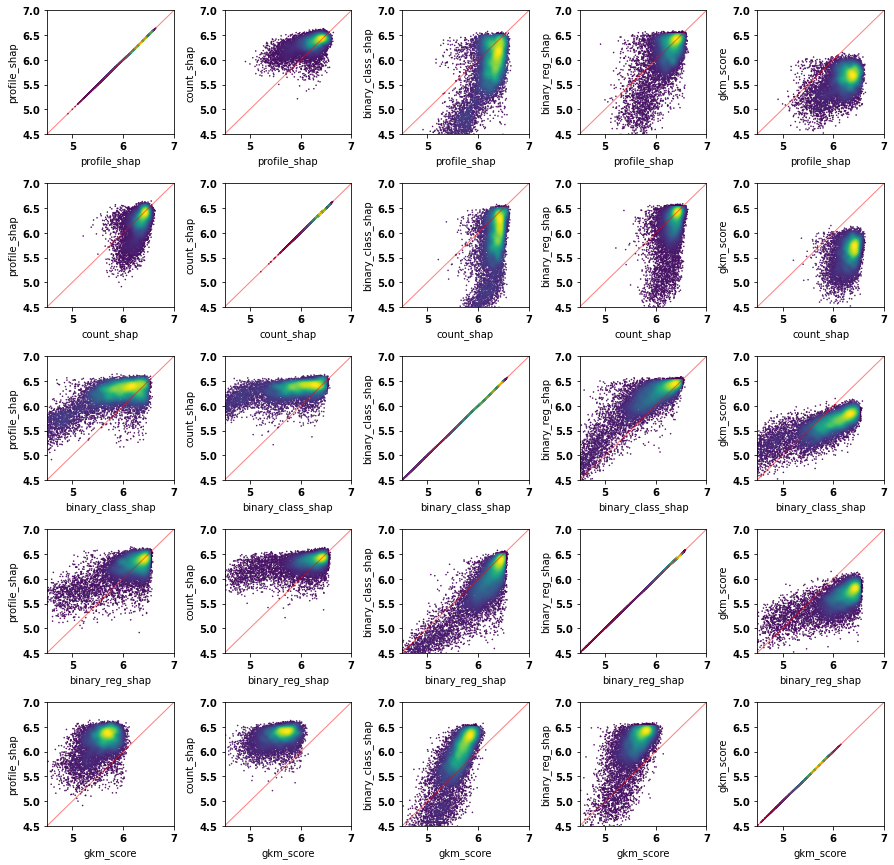

In [51]:
plt.rcParams["figure.figsize"]=15,15
fig,axes=plt.subplots(5,5)
for i in range(5):
    for j in range(5): 
        density_scatter(df.iloc[:,i].values,df.iloc[:,j].values,df.columns[i],df.columns[j], ax=axes[i,j])
        axes[i,j].plot((4.5, 7), (4.5, 7), linewidth=1, color='r',alpha=0.5)
        axes[i,j].set_xlabel(df.columns[i])
        axes[i,j].set_ylabel(df.columns[j])
        axes[i,j].set_xlim(4.5,7)
        axes[i,j].set_ylim(4.5,7)
plt.subplots_adjust(hspace=0.4)
plt.subplots_adjust(wspace=0.4)

plt.show()
